In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import wandb
from wandb.integration.keras import WandbCallback, WandbEvalCallback, WandbMetricsLogger



I0000 00:00:1774897454.543382   10247 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# 01 Task

# With tensorflow

In [3]:
# load data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Train:", x_train.shape)
print("Test:", x_test.shape)

/usr/local/lib/python3.11/dist-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [4]:
wandb.init(
    project="cnn-image-classification",
    config={
        "epochs": 50,
        "batch_size": 32,
        "learning_rate": 0.0001,
        "architecture": "CNN",
        "activation": "tanh"
    }
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: linneaborg03 (linneaborg03-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0 #To make the pixels range between 0 and 1  instead of 0 and 255

### first version

In [6]:
wandb.init(
    project="cnn-project",
    config={
        "epochs": 50,
        "batch_size": 32
    }
)

config = wandb.config

In [7]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), input_shape=(32,32,3)),
    layers.LeakyReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3)),
    layers.LeakyReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64),
    layers.LeakyReLU(),

    layers.Dense(10)  # 10 classes
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774897565.605578   10247 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 8620 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:21:00.0, compute capability: 7.5


In [8]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


In [9]:
model.fit(
    x_train, y_train,
    epochs=config.epochs,
    batch_size=config.batch_size,
    validation_split=0.15,
    callbacks=[WandbMetricsLogger()]
)

Epoch 1/50


I0000 00:00:1774897583.585907   10609 service.cc:153] XLA service 0x7f10d402f770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774897583.585941   10609 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1774897583.726336   10609 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774897583.791270   10609 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1774897583.901050   10609 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_690__.28


   5/1329 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.0972 - loss: 2.3195

I0000 00:00:1774897589.884449   10609 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1324/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1233 - loss: 2.3142

I0000 00:00:1774897605.779359   10665 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_690__.28


1329/1329 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.1256 - loss: 2.3069 - val_accuracy: 0.1184 - val_loss: 2.2981
Epoch 2/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.1221 - loss: 2.2932 - val_accuracy: 0.1196 - val_loss: 2.2888
Epoch 3/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.1252 - loss: 2.2857 - val_accuracy: 0.1259 - val_loss: 2.2820
Epoch 4/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.1306 - loss: 2.2793 - val_accuracy: 0.1345 - val_loss: 2.2758
Epoch 5/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.1400 - loss: 2.2732 - val_accuracy: 0.1456 - val_loss: 2.2697
Epoch 6/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.1547 - loss: 2.2667 - val_accuracy: 0.1591 - val_loss: 2.2630
Epoch 7/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.1671 - loss: 2.2593 - val_accuracy: 0.1743 - val_loss: 2.2554
Epoch 8/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.1812 - loss: 2.251

In [10]:
score = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3426 - loss: 1.8729


In [11]:
wandb.finish()

epoch/accuracy,▁▁▁▁▂▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,████▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁
epoch/val_accuracy,▁▁▁▂▂▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇█████
epoch/val_loss,█████▇▇▇▇▇▆▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
epoch/accuracy,0.34374
epoch/epoch,49
epoch/learning_rate,0.0001
epoch/loss,1.87233
epoch/val_accuracy,0.33653


### second version - with adam

In [12]:
wandb.init(
    project="cnn-project-adam",
    config={
        "epochs": 50,
        "batch_size": 32
    }
)

config = wandb.config

In [13]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), input_shape=(32,32,3)),
    layers.LeakyReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3)),
    layers.LeakyReLU(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64),
    layers.LeakyReLU(),

    layers.Dense(10)  # 10 classes
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [15]:
model.fit(
    x_train, y_train,
    epochs=config.epochs,
    batch_size=config.batch_size,
    validation_split=0.15,
    callbacks=[WandbMetricsLogger()]
)

Epoch 1/50


I0000 00:00:1774898871.284659   10618 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_317970__.28


1327/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3033 - loss: 1.9545

I0000 00:00:1774898888.761209   10662 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_317970__.28


1329/1329 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.3731 - loss: 1.7771 - val_accuracy: 0.4287 - val_loss: 1.6148
Epoch 2/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4740 - loss: 1.4970 - val_accuracy: 0.4923 - val_loss: 1.4403
Epoch 3/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.5184 - loss: 1.3757 - val_accuracy: 0.5197 - val_loss: 1.3634
Epoch 4/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5461 - loss: 1.2997 - val_accuracy: 0.5324 - val_loss: 1.3425
Epoch 5/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.5684 - loss: 1.2424 - val_accuracy: 0.5549 - val_loss: 1.2651
Epoch 6/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5846 - loss: 1.2013 - val_accuracy: 0.5820 - val_loss: 1.2186
Epoch 7/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5964 - loss: 1.1644 - val_accuracy: 0.5807 - val_loss: 1.2130
Epoch 8/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.6087 - loss: 1.1360

In [16]:
score = model.evaluate(x_test, y_test)
wandb.finish()

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6772 - loss: 0.9773


epoch/accuracy,▁▃▃▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇████████
epoch/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▄▄▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇█▇████████████
epoch/val_loss,█▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.78864
epoch/epoch,49
epoch/learning_rate,0.0001
epoch/loss,0.62989
epoch/val_accuracy,0.68267


### third version - with tanh

In [17]:
wandb.init(
    project="cnn-project-tanh",
    config={
        "epochs": 50,
        "batch_size": 32
    }
)

config = wandb.config

In [19]:
# Model
model = models.Sequential([

    layers.Conv2D(32, (3,3), input_shape=(32,32,3)),
    layers.Activation('tanh'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3)),
    layers.Activation('tanh'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64),
    layers.Activation('tanh'),

    layers.Dense(10)
])

# Optimizer Adam
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.fit(
    x_train, y_train,
    epochs=config.epochs,
    batch_size=config.batch_size,
    validation_split=0.15,
    callbacks=[WandbMetricsLogger()]
)

Epoch 1/50


I0000 00:00:1774907828.967544   10609 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_951276__.28


1326/1329 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4197 - loss: 1.6260

I0000 00:00:1774907862.611739   10609 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_951276__.28


1329/1329 ━━━━━━━━━━━━━━━━━━━━ 48s 33ms/step - accuracy: 0.4974 - loss: 1.4182 - val_accuracy: 0.5764 - val_loss: 1.2053
Epoch 2/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 72s 28ms/step - accuracy: 0.6118 - loss: 1.1058 - val_accuracy: 0.6245 - val_loss: 1.0806
Epoch 3/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - accuracy: 0.6592 - loss: 0.9830 - val_accuracy: 0.6367 - val_loss: 1.0528
Epoch 4/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.6893 - loss: 0.8955 - val_accuracy: 0.6477 - val_loss: 1.0107
Epoch 5/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.7197 - loss: 0.8090 - val_accuracy: 0.6499 - val_loss: 1.0222
Epoch 6/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.7448 - loss: 0.7416 - val_accuracy: 0.6565 - val_loss: 1.0165
Epoch 7/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.7683 - loss: 0.6731 - val_accuracy: 0.6567 - val_loss: 1.0300
Epoch 8/50
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - accuracy: 0.7931 - loss: 0.60

## Results

In [39]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy sur test set :", test_acc)

313/313 [==============================] - 1s 4ms/step - loss: 1.8535 - accuracy: 0.3498
Accuracy sur test set : 0.3497999906539917


## Tensorflow

# 02 Task

# with pytorch

In [40]:
import torchvision.transforms as transforms

# transform images and normalize
transform = transforms.Compose([
    transforms.ToTensor(),                
    transforms.Normalize((0.5,0.5,0.5),  
                         (0.5,0.5,0.5))
])

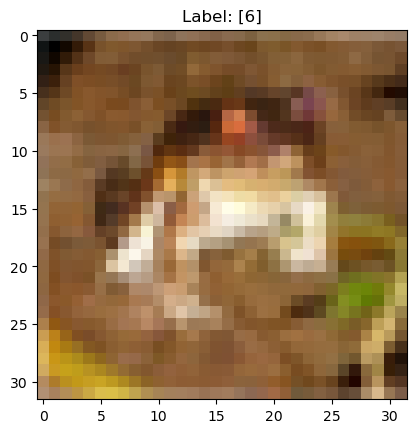

In [41]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0])
plt.title(f"Label: {y_train[0]}")
plt.show()

## Upload the data